# Antimeridian gap investigation — MODIS MOD11A2 LST

Tiles in column 35 (lon 170–180°E) and column 0 (lon −180–−170°) of the global tile grid
produce rectangular white gaps in `odc.stac.load()` output. This notebook traces the root
cause and validates the fix.

**Upstream issues:** odc-geo#176 · odc-stac#172 · odc-geo#208

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from icechunk_github_actions_demo import Config
from icechunk_github_actions_demo.processing import fetch_annual_lst
import rioxarray

In [2]:
config = Config("config/config_with_secrets_v1.txt")

In [3]:
tile_row, tile_col = 2, 35   # col 35: lon 170–180°E  (swap to col 0 to test the other side)
# tile_row, tile_col = 2, 0   # col  0: lon -180–-170°W

tile_geobox = config.tile_geobox(tile_row, tile_col)
bbox = tile_geobox.boundingbox
print(
    f"Tile ({tile_row}, {tile_col}): "
    f"lat [{bbox.bottom:.1f}, {bbox.top:.1f}], lon [{bbox.left:.1f}, {bbox.right:.1f}]"
)

Tile (2, 35): lat [60.0, 70.0], lon [170.0, 180.0]


In [7]:
import numpy as np
import odc.stac
import odc.geo.xr
import pystac_client
import planetary_computer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import shapely.geometry

STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

bbox = tile_geobox.boundingbox
year = 2020


#polygon = shapely.geometry.box(bbox.left, bbox.bottom, bbox.right, bbox.top)
catalog = pystac_client.Client.open(STAC_URL, modifier=planetary_computer.sign_inplace)
search = catalog.search(
    collections=["modis-11A2-061"],
    bbox=[bbox.left, bbox.bottom, bbox.right, bbox.top],
    #intersects=polygon,
    datetime=f"{year}-01-01/{year}-12-31",
)
print(
    f"Searching for MODIS MOD11A2 in {year} over tile ({tile_row}, {tile_col}): "
    f"lon [{bbox.left}, {bbox.right}], lat [{bbox.bottom}, {bbox.top}]"
)

Searching for MODIS MOD11A2 in 2020 over tile (2, 35): lon [170.0, 180.0], lat [60.0, 70.0]


In [8]:
items = search.item_collection()
print(f"Found {len(items)} items")

Found 368 items


## Root cause: `_relative_rois` fails near the antimeridian

The STAC search correctly returns all items — MODIS tiles h23–h26v02 cover the full output
tile and their bboxes extend to 180°. The bug is in **loading**, not in searching.

`odc.geo.overlap._relative_rois` computes pixel-space overlap during the MODIS sinusoidal →
EPSG:4326 coordinate transform. Near ±180° the round-trip places source pixels on the wrong
side of the antimeridian, so they are treated as non-overlapping with the output geobox →
nodata gap.

This affects **both** `geobox=tile_geobox` and `crs="epsg:4326"` no-geobox paths because
`_relative_rois` runs during the sinusoidal→WGS84 step in either case.

**Fix:** load into **UTM Zone 60N** (EPSG:32660, central meridian 177°E). The gap area
(175–180°E) sits near the centre of this zone, so `_relative_rois` never sees the ±180°
discontinuity. We then reproject only the 2D mean/max summaries back to the EPSG:4326 tile
geobox (reprojecting the full dask time-stack triggers a separate geometry bug in
`dask_rio_reproject`).

In [9]:
# --- Diagnostic: inspect which STAC items were returned and their native extents ---
print(f"Found {len(items)} items for tile ({tile_row}, {tile_col}) in {year}\n")
for item in items:
    left, bottom, right, top = item.bbox
    print(f"  {item.id}  bbox=[{left:.2f}, {bottom:.2f}, {right:.2f}, {top:.2f}]")

Found 368 items for tile (2, 35) in 2020

  MYD11A2.A2020361.h26v02.061.2021066190356  bbox=[160.03, 60.00, 180.00, 63.60]
  MYD11A2.A2020361.h25v02.061.2021066190350  bbox=[140.03, 60.00, 180.00, 67.10]
  MYD11A2.A2020361.h24v02.061.2021066190348  bbox=[120.02, 60.00, 180.00, 70.00]
  MYD11A2.A2020361.h23v02.061.2021066190337  bbox=[100.02, 60.00, 175.42, 70.00]
  MOD11A2.A2020361.h26v02.061.2021066191500  bbox=[160.03, 60.00, 180.00, 63.60]
  MOD11A2.A2020361.h25v02.061.2021066191422  bbox=[140.03, 60.00, 180.00, 67.10]
  MOD11A2.A2020361.h24v02.061.2021066191358  bbox=[120.02, 60.00, 180.00, 70.00]
  MOD11A2.A2020361.h23v02.061.2021066191324  bbox=[100.02, 60.00, 175.42, 70.00]
  MYD11A2.A2020353.h26v02.061.2021020063103  bbox=[160.03, 60.00, 180.00, 63.60]
  MYD11A2.A2020353.h25v02.061.2021020063109  bbox=[140.03, 60.00, 180.00, 67.10]
  MYD11A2.A2020353.h24v02.061.2021020063103  bbox=[120.02, 60.00, 180.00, 70.00]
  MYD11A2.A2020353.h23v02.061.2021020063110  bbox=[100.02, 60.00, 1

Unique tile footprints among 368 items: 8


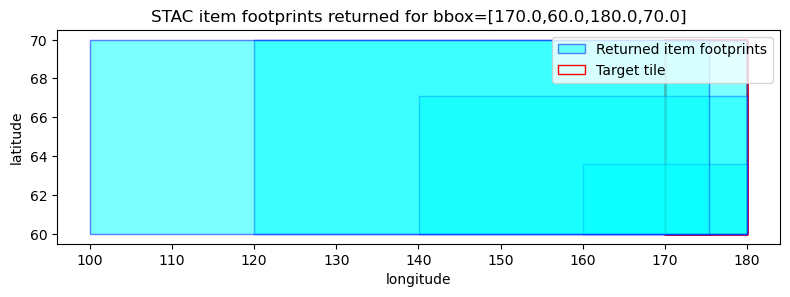

In [10]:
# --- Diagnostic: visualize item footprints to see coverage gaps ---
import geopandas as gpd
import shapely.geometry
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Build a GeoDataFrame from item footprints (using bbox, not geometry, for simplicity)
footprints = gpd.GeoDataFrame(
    [{"id": item.id} for item in items],
    geometry=[
        shapely.geometry.box(item.bbox[0], item.bbox[1], item.bbox[2], item.bbox[3])
        for item in items
    ],
    crs="epsg:4326",
)

# Get unique footprints (many items share the same tile footprint, just different dates)
unique_footprints = footprints.drop_duplicates(subset=["geometry"])
print(f"Unique tile footprints among {len(items)} items: {len(unique_footprints)}")

fig, ax = plt.subplots(figsize=(8, 6))
# Tile bbox we are trying to fill
tile_box = shapely.geometry.box(bbox.left, bbox.bottom, bbox.right, bbox.top)
gpd.GeoDataFrame(geometry=[tile_box], crs="epsg:4326").plot(
    ax=ax, facecolor="none", edgecolor="red", linewidth=2, label="Target tile"
)
unique_footprints.plot(ax=ax, facecolor="cyan", edgecolor="blue", alpha=0.3, linewidth=1)
ax.set_title(f"STAC item footprints returned for bbox=[{bbox.left},{bbox.bottom},{bbox.right},{bbox.top}]")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(handles=[
    mpatches.Patch(facecolor="cyan", edgecolor="blue", alpha=0.5, label="Returned item footprints"),
    mpatches.Patch(facecolor="none", edgecolor="red", label="Target tile"),
])
plt.tight_layout();

## Confirming the bug: both EPSG:4326 loading paths produce the same gap

We compare (a) loading with `crs="epsg:4326"` + bbox and reprojecting, and (b) loading with
`geobox=tile_geobox` directly. Both call `_relative_rois` during the sinusoidal→WGS84
transform, so both show an identical gap. The side-by-side plot confirms this.

In [11]:
# --- Buggy baseline: load WITH geobox (this is what produces the gaps) ---
ds_geobox = odc.stac.load(
    items,
    bands=["LST_Day_1km", "QC_Day"],
    geobox=tile_geobox,
    chunks={"time": 1, "x": config.PIXELS_PER_TILE, "y": config.PIXELS_PER_TILE},
)
print("With geobox:", ds_geobox)

With geobox: <xarray.Dataset> Size: 138MB
Dimensions:      (latitude: 1000, longitude: 1000, time: 46)
Coordinates:
  * latitude     (latitude) float64 8kB 70.0 69.98 69.98 ... 60.03 60.02 60.01
  * longitude    (longitude) float64 8kB 170.0 170.0 170.0 ... 180.0 180.0 180.0
  * time         (time) datetime64[us] 368B 2020-01-01 2020-01-09 ... 2020-12-26
    spatial_ref  int32 4B 4326
Data variables:
    LST_Day_1km  (time, latitude, longitude) uint16 92MB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    QC_Day       (time, latitude, longitude) uint8 46MB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>


## Fix: load into LAEA centred on tile centroid, reproject 2D summaries to EPSG:4326

For antimeridian tiles, `_relative_rois` miscomputes pixel overlap during the
sinusoidal→EPSG:4326 reprojection near ±180°.  The fix:

1. Choose a Lambert Azimuthal Equal Area (LAEA) projection centred on the **tile
   centroid** (e.g. 175°E / 65°N for row 2 col 35).  The antimeridian sits 5° from
   the projection origin, so `_relative_rois` never encounters the ±180°
   discontinuity.
2. Expand the bbox ±1° before loading so STAC item geometry edges (capped at ±180°)
   fall strictly *inside* the output geobox, avoiding a floating-point boundary
   coincidence that dropped the last pixel column.
3. Compute mean/max in LAEA space (2D arrays), then `.odc.reproject(tile_geobox)` to
   clip back to the final EPSG:4326 extent.  (Reprojecting the full dask time-stack
   triggers a separate bug in `dask_rio_reproject`.)


In [12]:
from icechunk_github_actions_demo.processing import _crs_for_antimeridian_tile
import odc.geo.xr
import numpy as np

# LAEA centred on the tile centroid keeps ±180° 5° from the projection origin,
# so _relative_rois never sees the sinusoidal→EPSG:4326 ±180° discontinuity and
# STAC item bbox edges (capped at ±180°) fall strictly inside the output geobox.
proj_crs = _crs_for_antimeridian_tile(bbox)
MODIS_RESOLUTION_M = 1000  # native MODIS ~1 km

print(f"Using CRS: {proj_crs}")

laea_ds = odc.stac.load(
    items,
    bands=["LST_Day_1km", "QC_Day"],
    crs=proj_crs,
    resolution=MODIS_RESOLUTION_M,
    bbox=[bbox.left - 1, bbox.bottom - 1, bbox.right + 1, bbox.top + 1],
    chunks={"time": 1},
)
print("Loaded in LAEA:", laea_ds)

# Apply QC filter and scale in projected space, then compute the full time stack.
# Reproject only the 2D mean/max — reprojecting the full dask time-stack hits a
# geometry bug in dask_rio_reproject (GeoboxTiles.grid_intersect fails to close a
# LinearRing for large projected footprints).
good_da = (laea_ds.QC_Day & 0b11) <= 1
lst_laea_da = (
    laea_ds.LST_Day_1km.where(good_da).where(laea_ds.LST_Day_1km >= 7500) * 0.02
)
lst_laea_da = lst_laea_da.compute()
print(f"\nComputed {len(lst_laea_da.time)} time steps in LAEA")

avg_lst_laea_da = lst_laea_da.mean("time")
max_lst_laea_da = lst_laea_da.max("time")

avg_lst_da = avg_lst_laea_da.odc.reproject(tile_geobox, resampling="nearest")
max_lst_da = max_lst_laea_da.odc.reproject(tile_geobox, resampling="nearest")
avg_lst_da


Using CRS: +proj=laea +lat_0=65.0000 +lon_0=175.0000 +datum=WGS84 +units=m +no_defs
Loaded in LAEA: <xarray.Dataset> Size: 127MB
Dimensions:      (y: 1333, x: 690, time: 46)
Coordinates:
  * y            (y) float64 11kB 6.795e+05 6.785e+05 ... -6.515e+05 -6.525e+05
  * x            (x) float64 6kB -3.445e+05 -3.435e+05 ... 3.435e+05 3.445e+05
  * time         (time) datetime64[us] 368B 2020-01-01 2020-01-09 ... 2020-12-26
    spatial_ref  int32 4B 0
Data variables:
    LST_Day_1km  (time, y, x) uint16 85MB dask.array<chunksize=(1, 1333, 690), meta=np.ndarray>
    QC_Day       (time, y, x) uint8 42MB dask.array<chunksize=(1, 1333, 690), meta=np.ndarray>

Computed 46 time steps in LAEA


<xarray.DataArray (latitude: 1000, longitude: 1000)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1000, 1000), dtype=float32)
Coordinates:
  * latitude     (latitude) float64 8kB 70.0 69.98 69.98 ... 60.03 60.02 60.01
  * longitude    (longitude) float64 8kB 170.0 170.0 170.0 ... 180.0 180.0 180.0
    spatial_ref  int32 4B 4326

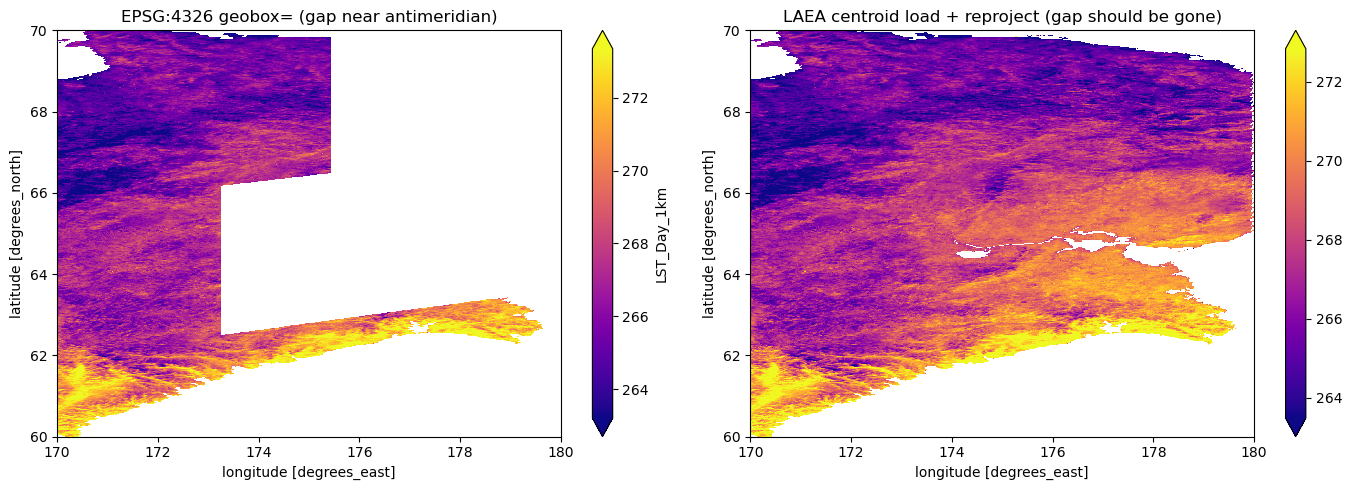

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

good_geobox = (ds_geobox.QC_Day & 0b11) <= 1
lst_geobox_mean_da = (
    ds_geobox.LST_Day_1km.where(good_geobox).where(ds_geobox.LST_Day_1km >= 7500) * 0.02
).compute().mean("time")
lst_geobox_mean_da.plot.imshow(ax=axes[0], robust=True, cmap="plasma")
axes[0].set_title("EPSG:4326 geobox= (gap near antimeridian)")

avg_lst_da.plot.imshow(ax=axes[1], robust=True, cmap="plasma")
axes[1].set_title("LAEA centroid load + reproject (gap should be gone)")
plt.tight_layout()


## Experiment: dual-search — load items from both sides of the antimeridian

For col 35 (170–180°E) the MODIS tiles whose STAC footprints are capped at
exactly 180°E may leave a sub-pixel gap at the antimeridian edge.  Items for
col 0 (−180 to −170°W) begin exactly at 180°E in LAEA space; loading them
alongside the col 35 items could fill that gap.


In [14]:
# Search for MODIS items on the other side of the antimeridian
# Col 35 far side = col 0 region: -180 to -170°W
catalog_far = pystac_client.Client.open(STAC_URL, modifier=planetary_computer.sign_inplace)
items_far_side = catalog_far.search(
    collections=["modis-11A2-061"],
    bbox=[-180, bbox.bottom, -170, bbox.top],
    datetime=f"{year}-01-01/{year}-12-31",
).item_collection()
print(f"Near-side items: {len(items)}")
print(f"Far-side items:  {len(items_far_side)}")

# Deduplicate by ID (some tiles may appear in both searches)
items_combined = list({item.id: item for item in [*items, *items_far_side]}.values())
print(f"Combined unique: {len(items_combined)}")


Near-side items: 368
Far-side items:  368
Combined unique: 736


In [ ]:
# Load combined items in LAEA — far-side tiles extend LAEA coverage past x=500,000
# (past 180°E), potentially filling the antimeridian gap.
laea_combined_ds = odc.stac.load(
    items_combined,
    bands=["LST_Day_1km", "QC_Day"],
    crs=proj_crs,
    resolution=1000, 
    bbox=[bbox.left - 1, bbox.bottom - 1, bbox.right + 1, bbox.top + 1],
    chunks={"time": 1},
)
print("Combined LAEA dataset:", laea_combined_ds)

good_combined_da = (laea_combined_ds.QC_Day & 0b11) <= 1
lst_laea_combined_da = (
    laea_combined_ds.LST_Day_1km
    .where(good_combined_da)
    .where(laea_combined_ds.LST_Day_1km >= 7500) * 0.02
).compute()
print(f"Computed {len(lst_laea_combined_da.time)} time steps")

avg_lst_laea_combined_da = lst_laea_combined_da.mean("time")
avg_lst_combined_da = avg_lst_laea_combined_da.odc.reproject(tile_geobox, resampling="nearest")
avg_lst_combined_da


Combined LAEA dataset: <xarray.Dataset> Size: 507MB
Dimensions:      (y: 2664, x: 1380, time: 46)
Coordinates:
  * y            (y) float64 21kB 6.792e+05 6.788e+05 ... -6.518e+05 -6.522e+05
  * x            (x) float64 11kB -3.448e+05 -3.442e+05 ... 3.442e+05 3.448e+05
  * time         (time) datetime64[us] 368B 2020-01-01 2020-01-09 ... 2020-12-26
    spatial_ref  int32 4B 0
Data variables:
    LST_Day_1km  (time, y, x) uint16 338MB dask.array<chunksize=(1, 2664, 1380), meta=np.ndarray>
    QC_Day       (time, y, x) uint8 169MB dask.array<chunksize=(1, 2664, 1380), meta=np.ndarray>
Computed 46 time steps


<xarray.DataArray (latitude: 1000, longitude: 1000)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1000, 1000), dtype=float32)
Coordinates:
  * latitude     (latitude) float64 8kB 70.0 69.98 69.98 ... 60.03 60.02 60.01
  * longitude    (longitude) float64 8kB 170.0 170.0 170.0 ... 180.0 180.0 180.0
    spatial_ref  int32 4B 4326

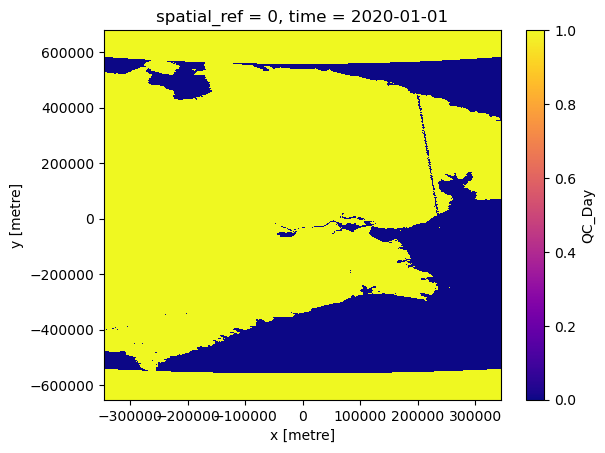

In [ ]:
# seam in data when first loaded in odc stac even with equal area proj
good_combined_da.isel(time=0).astype(int).plot.imshow(robust=True, cmap="plasma")

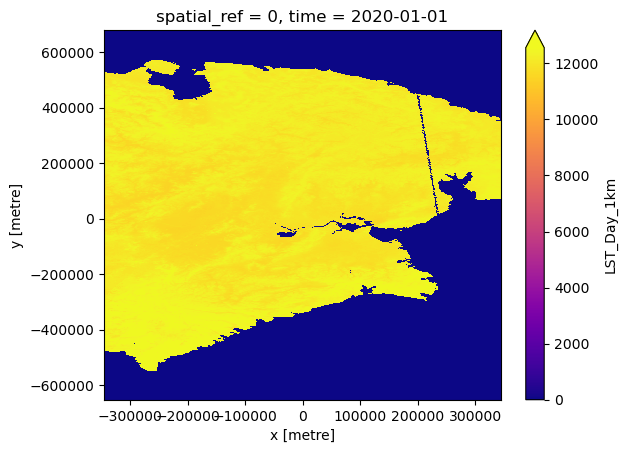

In [34]:
laea_combined_ds.LST_Day_1km.isel(time=0).plot.imshow(robust=True, cmap="plasma")

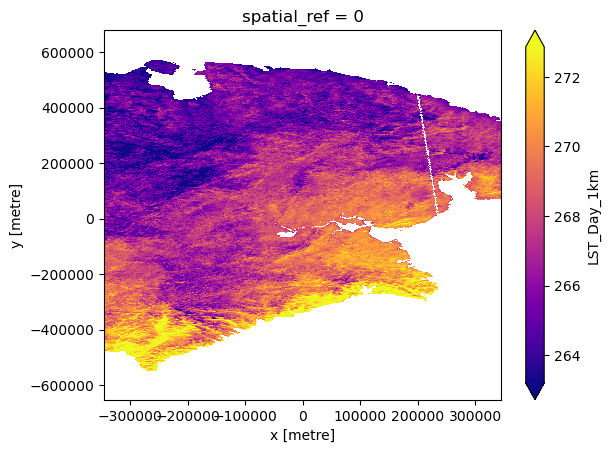

In [28]:
avg_lst_laea_combined_da.plot.imshow(robust=True, cmap="plasma")

(0.0, 500000.0)

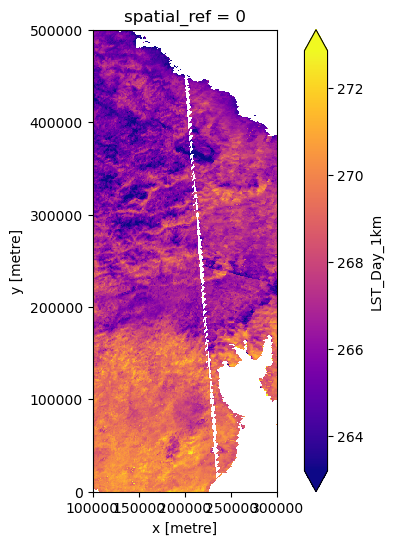

In [30]:
f,ax=plt.subplots(figsize=(7, 6))
avg_lst_laea_combined_da.plot.imshow(robust=True, cmap="plasma")
ax.set_aspect("equal")
ax.set_xlim([100_000, 300_000])
ax.set_ylim([0, 500_000])

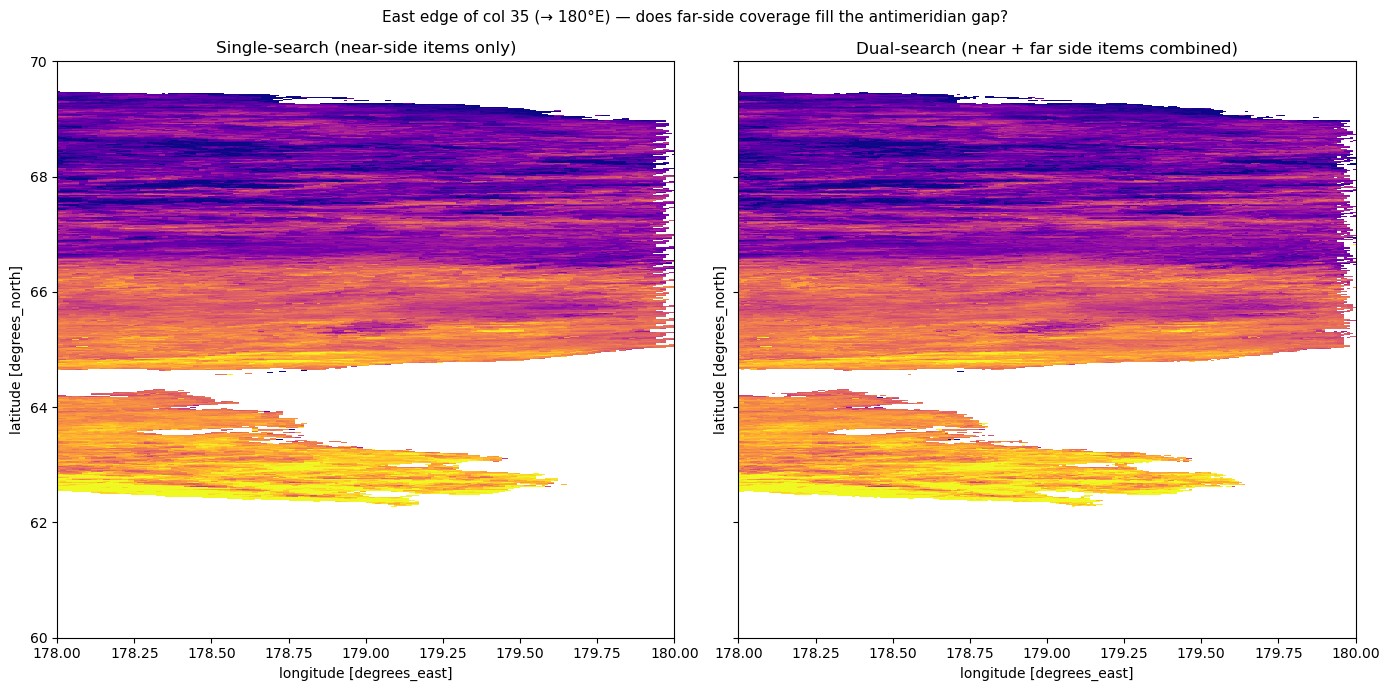

In [27]:
# Compare single-search vs dual-search near the antimeridian edge
import numpy as np
import matplotlib.pyplot as plt

N = 200  # rightmost 200 km of col 35 (approaching 180°E)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
kw = dict(robust=True, cmap="plasma", add_colorbar=False)

avg_lst_da.isel(longitude=slice(-N, None)).plot.imshow(ax=axes[0], **kw)
axes[0].set_title("Single-search (near-side items only)")

avg_lst_combined_da.isel(longitude=slice(-N, None)).plot.imshow(ax=axes[1], **kw)
axes[1].set_title("Dual-search (near + far side items combined)")

fig.suptitle(
    "East edge of col 35 (→ 180°E) — does far-side coverage fill the antimeridian gap?",
    fontsize=11,
)
plt.tight_layout()
plt.show()


## Cross-tile comparison: col 35 (170–180°E) and col 0 (−180–−170°W) side by side


In [17]:
# --- Cross-tile comparison setup: search for col 0 items ---
tile_geobox_col0 = config.tile_geobox(2, 0)
bbox_col0 = tile_geobox_col0.boundingbox
print(f"Col 0: lat [{bbox_col0.bottom:.1f}, {bbox_col0.top:.1f}], lon [{bbox_col0.left:.1f}, {bbox_col0.right:.1f}]")

catalog_col0 = pystac_client.Client.open(STAC_URL, modifier=planetary_computer.sign_inplace)
items_col0 = catalog_col0.search(
    collections=["modis-11A2-061"],
    bbox=[bbox_col0.left, bbox_col0.bottom, bbox_col0.right, bbox_col0.top],
    datetime=f"{year}-01-01/{year}-12-31",
).item_collection()
print(f"Found {len(items_col0)} items for col 0")

Col 0: lat [60.0, 70.0], lon [-180.0, -170.0]
Found 368 items for col 0


In [18]:
# --- OLD approach: geobox= (buggy) for col 35 and col 0 ---
good_col35_da = (ds_geobox.QC_Day & 0b11) <= 1
avg_lst_col35_old_da = (
    ds_geobox.LST_Day_1km.where(good_col35_da).where(ds_geobox.LST_Day_1km >= 7500) * 0.02
).compute().mean("time")

geobox_col0_ds = odc.stac.load(
    items_col0,
    bands=["LST_Day_1km", "QC_Day"],
    geobox=tile_geobox_col0,
    chunks={"time": 1, "x": config.PIXELS_PER_TILE, "y": config.PIXELS_PER_TILE},
)
good_col0_old_da = (geobox_col0_ds.QC_Day & 0b11) <= 1
avg_lst_col0_old_da = (
    geobox_col0_ds.LST_Day_1km.where(good_col0_old_da).where(geobox_col0_ds.LST_Day_1km >= 7500) * 0.02
).compute().mean("time")

print("OLD: col35 shape", avg_lst_col35_old_da.shape, "| col0 shape", avg_lst_col0_old_da.shape)


OLD: col35 shape (1000, 1000) | col0 shape (1000, 1000)


In [19]:
# --- NEW approach: LAEA centroid load + bbox±1° for both tiles ---
# Col 35: re-use avg_lst_da computed above
avg_lst_col35_new_da = avg_lst_da

# Col 0: LAEA centred at its tile centroid (-175°, mid-latitude), bbox expanded ±1°
proj_crs_col0 = _crs_for_antimeridian_tile(bbox_col0)
laea_col0_ds = odc.stac.load(
    items_col0,
    bands=["LST_Day_1km", "QC_Day"],
    crs=proj_crs_col0,
    resolution=1000,
    bbox=[bbox_col0.left - 1, bbox_col0.bottom - 1, bbox_col0.right + 1, bbox_col0.top + 1],
    chunks={"time": 1},
)
good_col0_da = (laea_col0_ds.QC_Day & 0b11) <= 1
lst_laea_col0_da = (
    laea_col0_ds.LST_Day_1km.where(good_col0_da).where(laea_col0_ds.LST_Day_1km >= 7500) * 0.02
).compute()
avg_lst_col0_new_da = lst_laea_col0_da.mean("time").odc.reproject(
    tile_geobox_col0, resampling="nearest"
)

print("NEW: col35 shape", avg_lst_col35_new_da.shape, "| col0 shape", avg_lst_col0_new_da.shape)


NEW: col35 shape (1000, 1000) | col0 shape (1000, 1000)


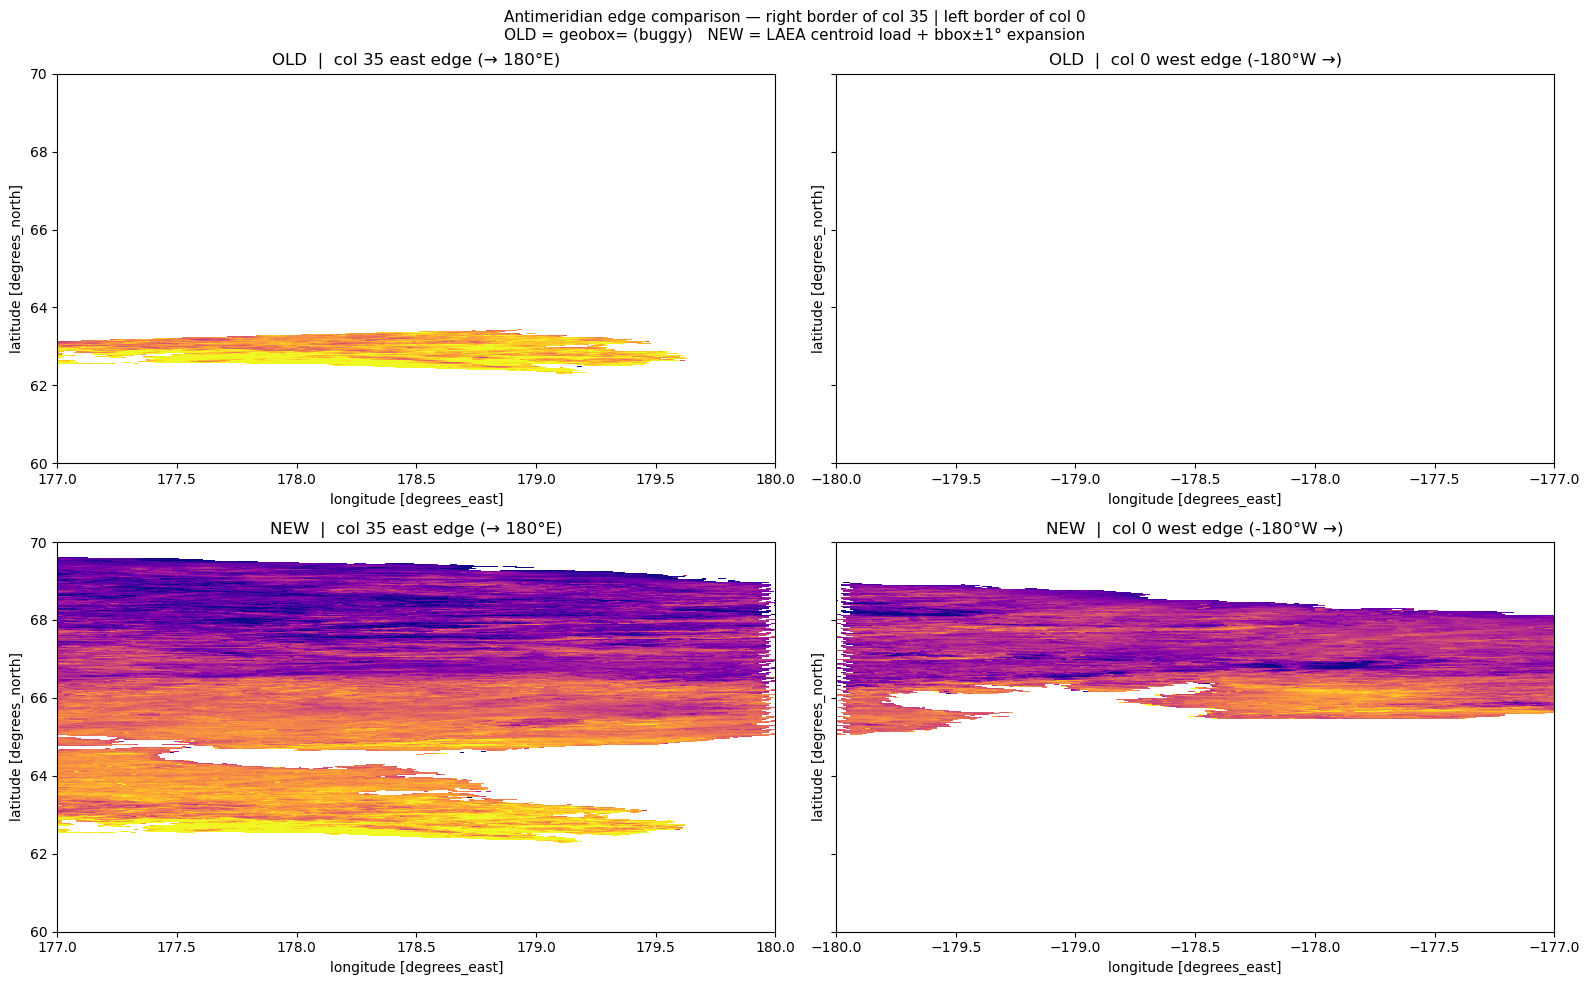

In [20]:
# --- Comparison plot: right edge of col 35 and left edge of col 0 near ±180° ---
N = 300  # 300 px (300 km at 1 km resolution) on each side of the antimeridian

# Normalise dim names: geobox= path produces x/y, LAEA path produces longitude/latitude
def _to_lonlat(da):
    rename = {}
    if "x" in da.dims:
        rename["x"] = "longitude"
    if "y" in da.dims:
        rename["y"] = "latitude"
    return da.rename(rename) if rename else da

avg_lst_col35_old_da = _to_lonlat(avg_lst_col35_old_da)
avg_lst_col0_old_da  = _to_lonlat(avg_lst_col0_old_da)
avg_lst_col35_new_da = _to_lonlat(avg_lst_col35_new_da)
avg_lst_col0_new_da  = _to_lonlat(avg_lst_col0_new_da)

import numpy as np
all_vals = np.concatenate([
    avg_lst_col35_old_da.values.ravel(), avg_lst_col0_old_da.values.ravel(),
    avg_lst_col35_new_da.values.ravel(), avg_lst_col0_new_da.values.ravel(),
])
vmin, vmax = np.nanpercentile(all_vals, [2, 98])

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
kw = dict(vmin=vmin, vmax=vmax, cmap="plasma", add_colorbar=False)

avg_lst_col35_old_da.isel(longitude=slice(-N, None)).plot.imshow(ax=axes[0, 0], **kw)
axes[0, 0].set_title("OLD  |  col 35 east edge (→ 180°E)")

avg_lst_col0_old_da.isel(longitude=slice(None, N)).plot.imshow(ax=axes[0, 1], **kw)
axes[0, 1].set_title("OLD  |  col 0 west edge (-180°W →)")

avg_lst_col35_new_da.isel(longitude=slice(-N, None)).plot.imshow(ax=axes[1, 0], **kw)
axes[1, 0].set_title("NEW  |  col 35 east edge (→ 180°E)")

avg_lst_col0_new_da.isel(longitude=slice(None, N)).plot.imshow(ax=axes[1, 1], **kw)
axes[1, 1].set_title("NEW  |  col 0 west edge (-180°W →)")

fig.suptitle(
    "Antimeridian edge comparison — right border of col 35 | left border of col 0\n"
    "OLD = geobox= (buggy)   NEW = LAEA centroid load + bbox±1° expansion",
    fontsize=11,
)
plt.tight_layout()
plt.show()


## Joint TM-180 visualization — both tiles on a common projected grid


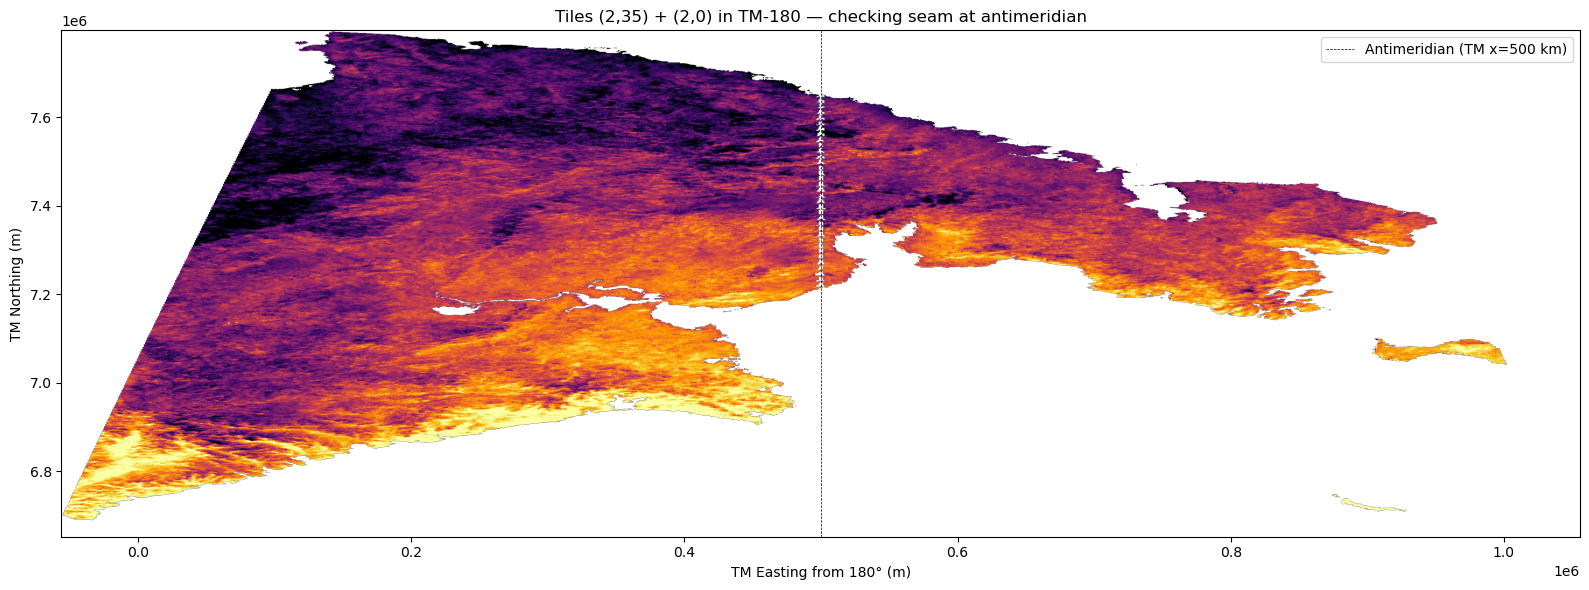

In [21]:
# Reproject both tiles to TM-180 for joint visualization to inspect the antimeridian seam.
# TM centred at 180° is used only here — production code uses LAEA centred on tile centroid.
import rioxarray
import numpy as np
import matplotlib.pyplot as plt

_VIZ_TM_180 = (
    "+proj=tmerc +lat_0=0 +lon_0=180 +k=0.9996 "
    "+x_0=500000 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

col35_tm_da = avg_lst_da.rio.write_crs("EPSG:4326").rio.reproject(_VIZ_TM_180)
col0_tm_da  = avg_lst_col0_new_da.rio.write_crs("EPSG:4326").rio.reproject(_VIZ_TM_180)

all_vals = np.concatenate([
    col35_tm_da.values[np.isfinite(col35_tm_da.values) & (col35_tm_da.values > 0)],
    col0_tm_da.values[np.isfinite(col0_tm_da.values) & (col0_tm_da.values > 0)],
])
vmin, vmax = np.percentile(all_vals, [2, 98]) if len(all_vals) else (150, 330)

f, ax = plt.subplots(figsize=(16, 6))
for tm_da in [col35_tm_da, col0_tm_da]:
    ax.imshow(
        tm_da.values,
        extent=[float(tm_da.x.min()), float(tm_da.x.max()),
                float(tm_da.y.min()), float(tm_da.y.max())],
        origin="upper", vmin=vmin, vmax=vmax, cmap="inferno", aspect="auto",
    )
ax.axvline(500_000, color="black", lw=0.5, ls="--", label="Antimeridian (TM x=500 km)")
ax.set_xlabel("TM Easting from 180° (m)")
ax.set_ylabel("TM Northing (m)")
ax.set_title("Tiles (2,35) + (2,0) in TM-180 — checking seam at antimeridian")
ax.legend()
f.tight_layout()


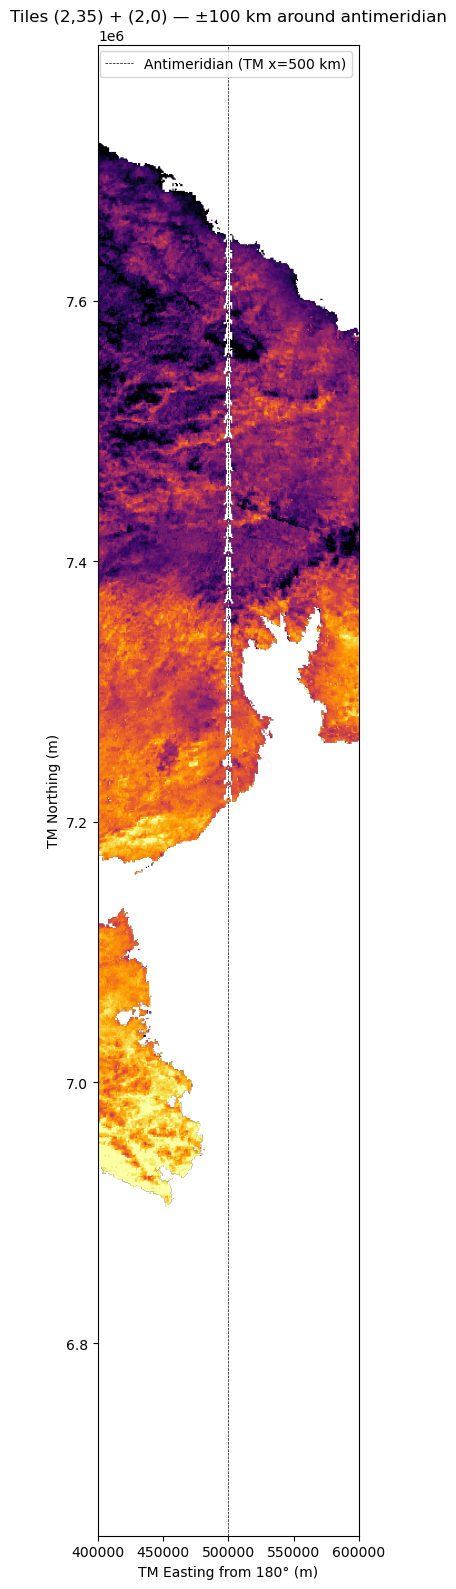

In [22]:
f, ax = plt.subplots(figsize=(6, 16))
for tm_da in [col35_tm_da, col0_tm_da]:
    ax.imshow(
        tm_da.values,
        extent=[float(tm_da.x.min()), float(tm_da.x.max()),
                float(tm_da.y.min()), float(tm_da.y.max())],
        origin="upper", vmin=vmin, vmax=vmax, cmap="inferno", aspect="auto",
    )
ax.axvline(500_000, color="black", lw=0.5, ls="--", label="Antimeridian (TM x=500 km)")
ax.set_xlabel("TM Easting from 180° (m)")
ax.set_ylabel("TM Northing (m)")
ax.set_title("Tiles (2,35) + (2,0) — ±100 km around antimeridian")
ax.set_xlim(400_000, 600_000)
ax.set_aspect("equal")
ax.legend()
f.tight_layout()


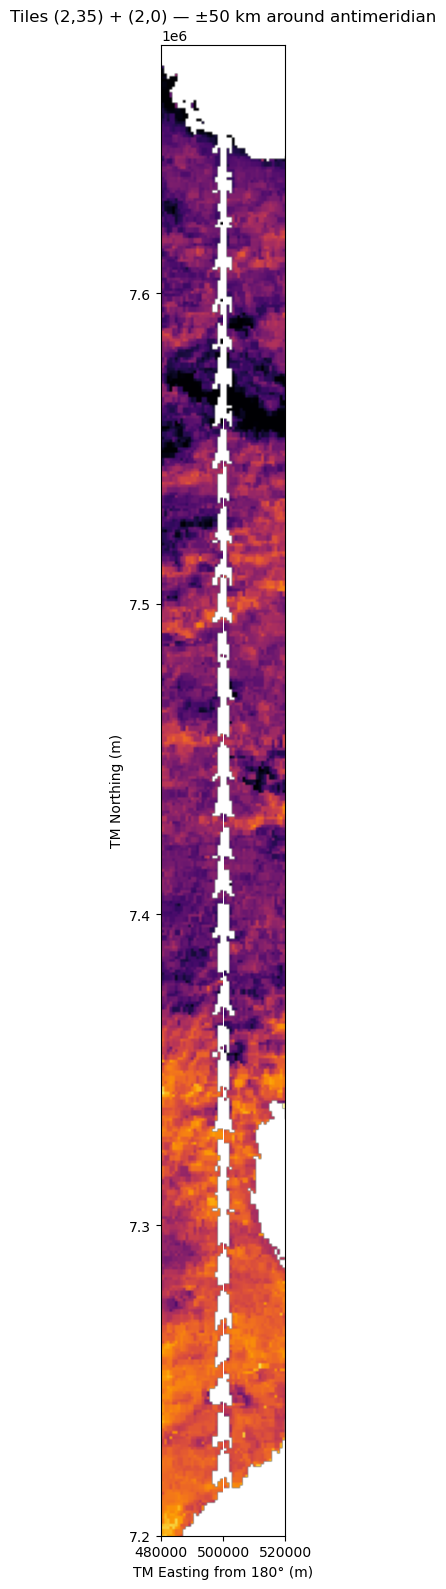

In [25]:
f, ax = plt.subplots(figsize=(6, 16))
for tm_da in [col35_tm_da, col0_tm_da]:
    ax.imshow(
        tm_da.values,
        extent=[float(tm_da.x.min()), float(tm_da.x.max()),
                float(tm_da.y.min()), float(tm_da.y.max())],
        origin="upper", vmin=vmin, vmax=vmax, cmap="inferno", aspect="auto",
    )
ax.set_xlabel("TM Easting from 180° (m)")
ax.set_ylabel("TM Northing (m)")
ax.set_title("Tiles (2,35) + (2,0) — ±50 km around antimeridian")
ax.set_xlim(480_000, 520_000)
ax.set_ylim(7_200_000, 7_680_000)
ax.set_aspect("equal")
f.tight_layout()
